In [1]:
import sys
import os

# Move one directory up (to project root)
project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Added to PYTHONPATH:", project_root)

Added to PYTHONPATH: /vols/cms/mm1221/geant4sim/scripts/validation_new


In [2]:
import numpy as np
import pandas as pd
import awkward as ak

from src.data_loader.Data_Loader import Data_Loader
from src.models.model_loader import model_loader
from src.clustering.clusterer import clusterer
from src.metrics.build_dataframe import build_dataframe

In [4]:
loader = Data_Loader(
    root="/vols/cms/mm1221/geant4sim/simulations/build/Test_EM_2_5/raw/split_0000.root",
    split="test",
    max_events=100,
    batch_size=1,
    shuffle=False,
    follow_batch=["x"],
)

### Loading ROOT file: /vols/cms/mm1221/geant4sim/simulations/build/Test_EM_2_5/raw/split_0000.root
Loaded 100 events


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_cuda/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [5]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_config = {
    "task": "contrastive",
    "hidden_dim": 64,
    "num_layers": 3,
    "dropout": 0.01,
    "k": 24,

    "contrastive_dim": 16,
    "coord_dim": 3,
    "path" : "/vols/cms/mm1221/geant4sim/scripts/training/Contrastive/runs/EM_2_5/best_model.pt"
}

model = model_loader(
    config=model_config,
    device = device
)

print(f"Model loaded successfully")


Model loaded successfully


In [6]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

import pandas as pd
from tqdm import tqdm


In [15]:
all_cluster_labels = []
all_predictions = []
for i, data in enumerate(loader):
    data = data.to(device)
    out = model(data.x, data.x_batch)
    preds = out[0]
    all_predictions.append(preds)
    #xyz = data.x[:, :3].detach().cpu().numpy()
    """
    k = 16
    connectivity = kneighbors_graph(
        xyz,
        n_neighbors=k,
        mode="connectivity",
        include_self=True,
        n_jobs=-1,
    )
    """
    
    agglomerative = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=0.2,
        linkage="average",         
        metric="cosine",
        #connectivity = connectivity
    )

    preds_np = preds.detach().cpu().numpy()
    cluster_labels = agglomerative.fit_predict(preds_np)

    all_cluster_labels.append(cluster_labels)

    print(i)
    if i > 4:
        break

0
1
2
3
4
5


In [20]:
print(len(all_predictions[3]))
data = loader[3]

2284


TypeError: 'DataLoader' object is not subscriptable

In [21]:
total_off = 0
for i, data in enumerate(loader):
    num_reco = np.max(all_cluster_labels[i])
    num_cp = np.unique(data.assoc[i])
    offset = num_reco - num_cp
    total_off += offset
    if i > 5:
        break

print(total_off)

[20]


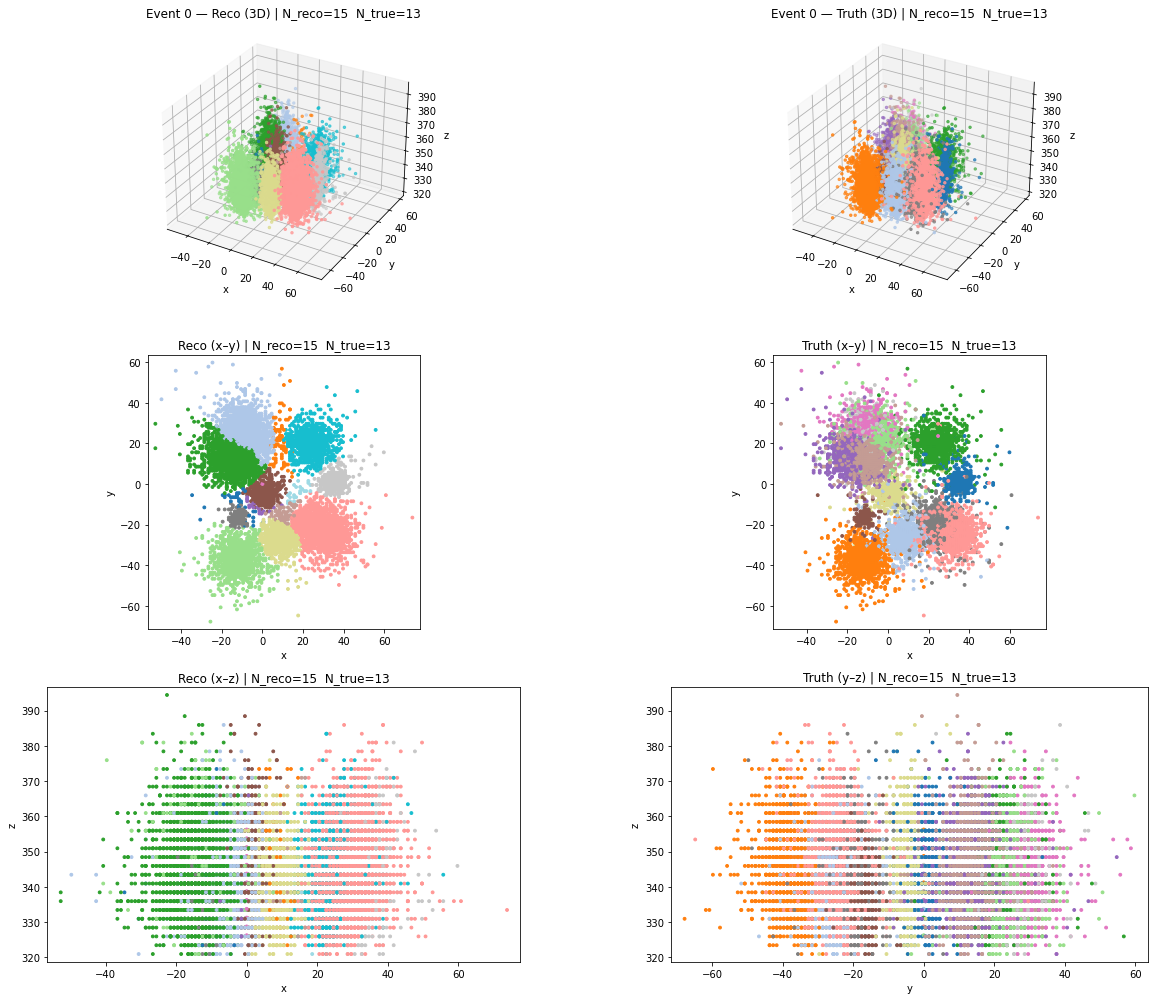

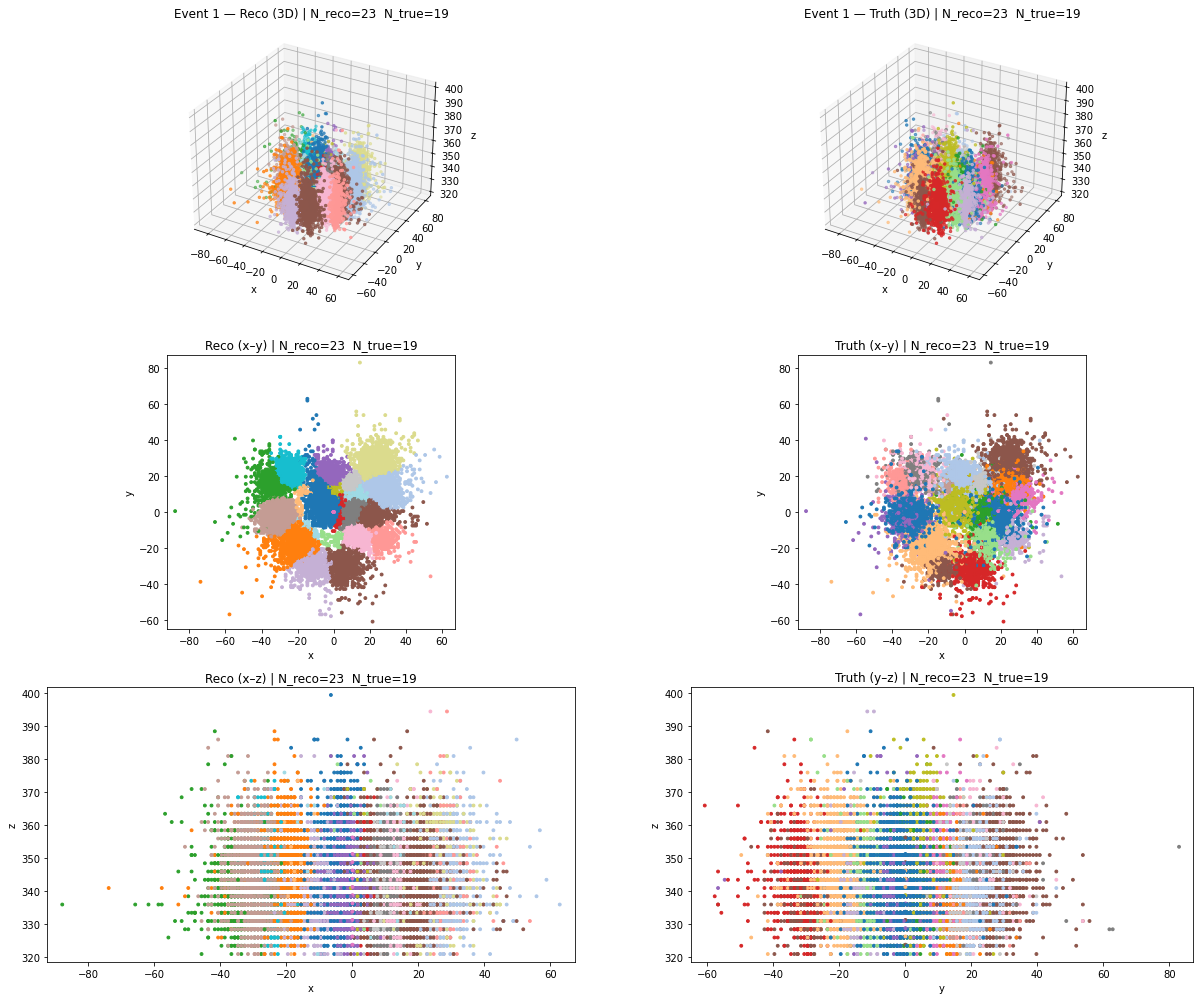

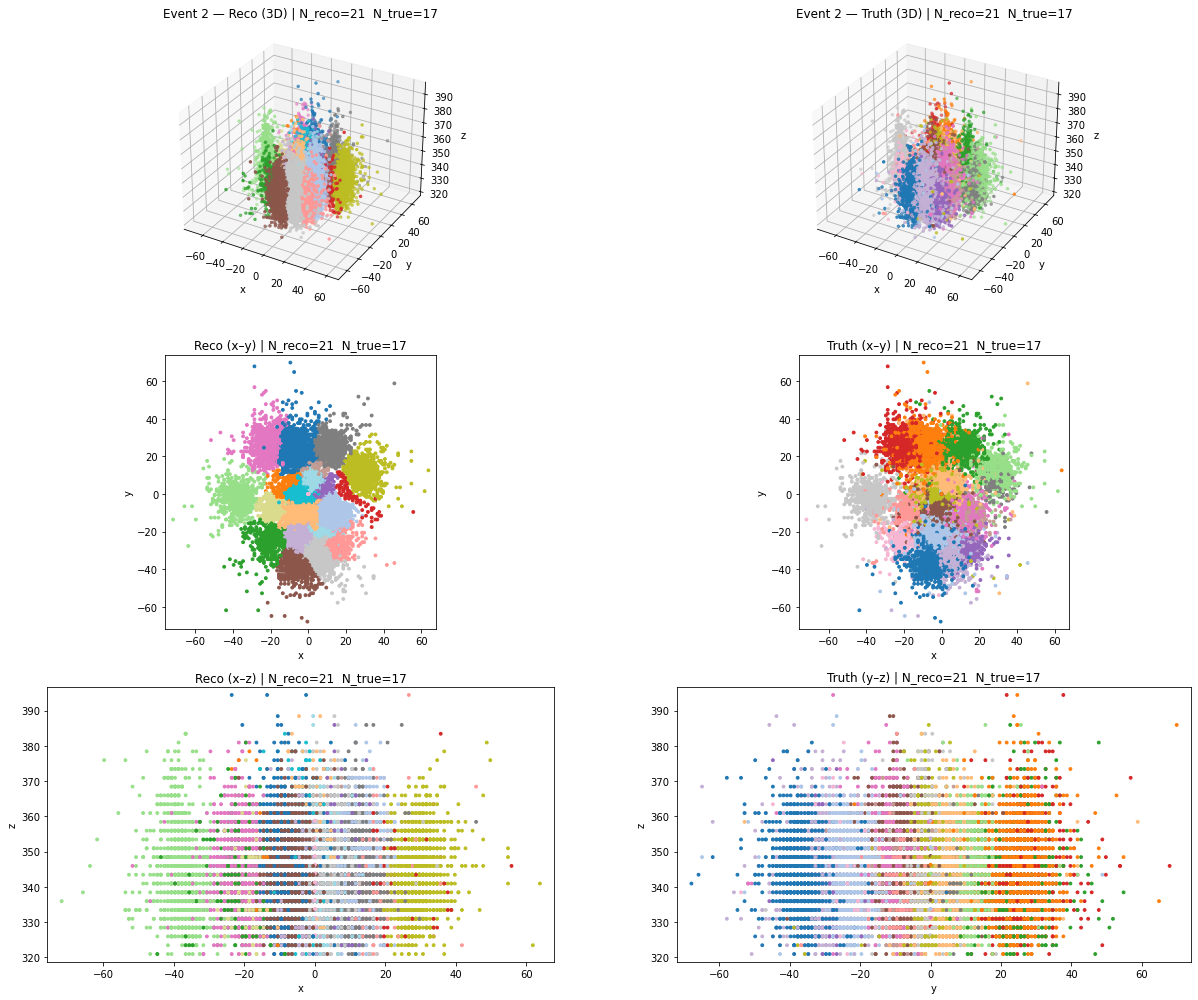

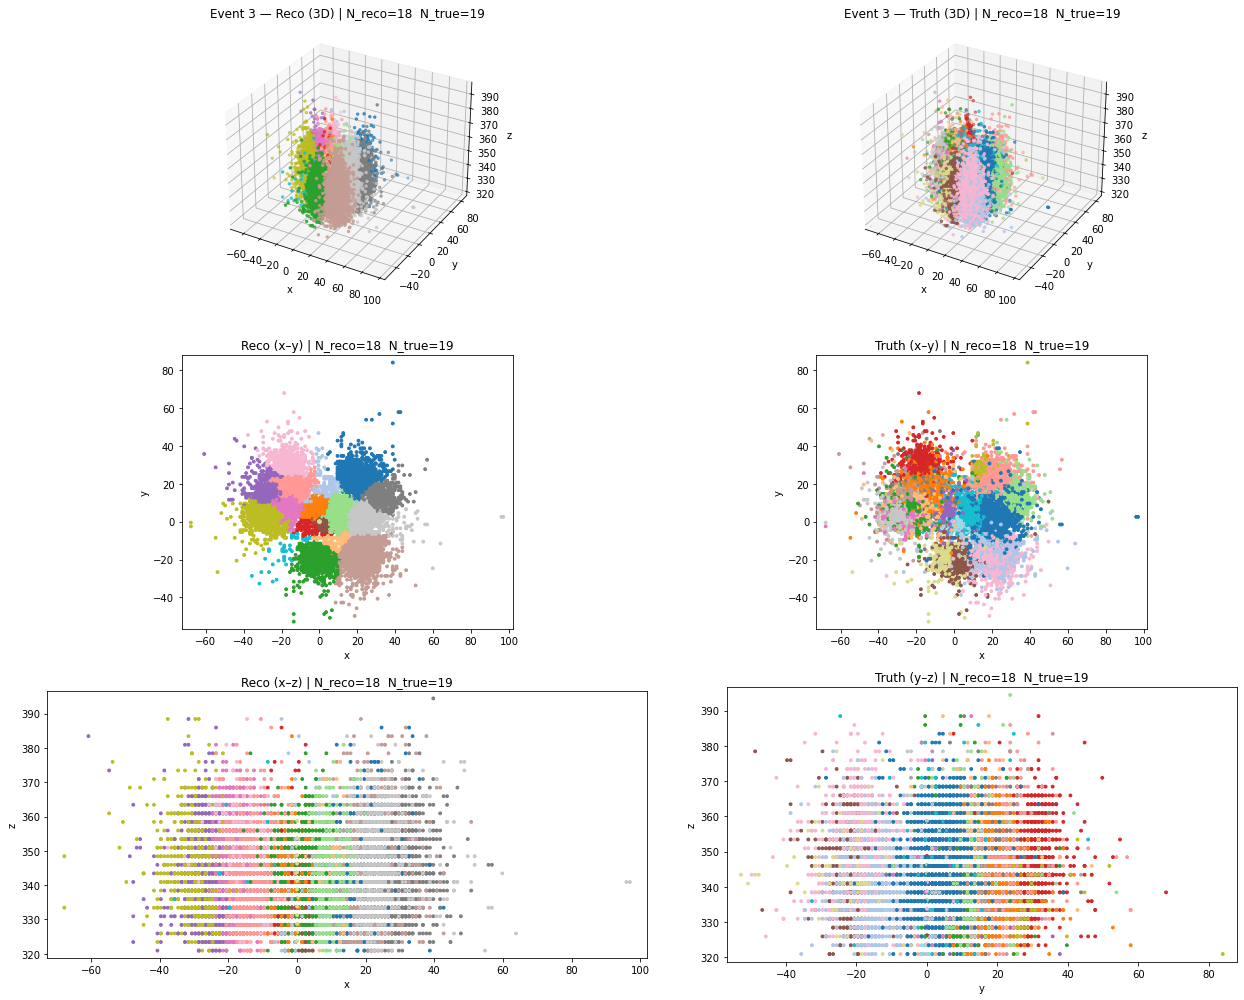

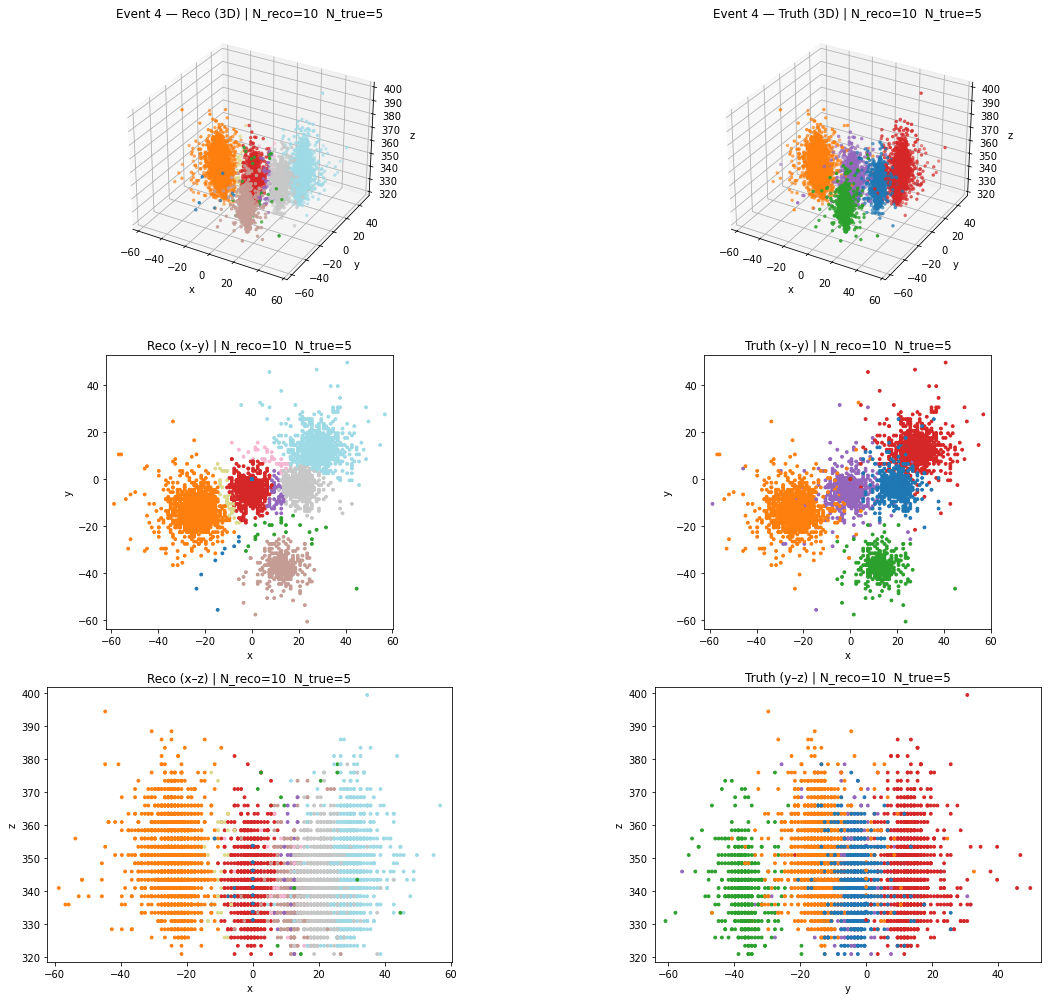

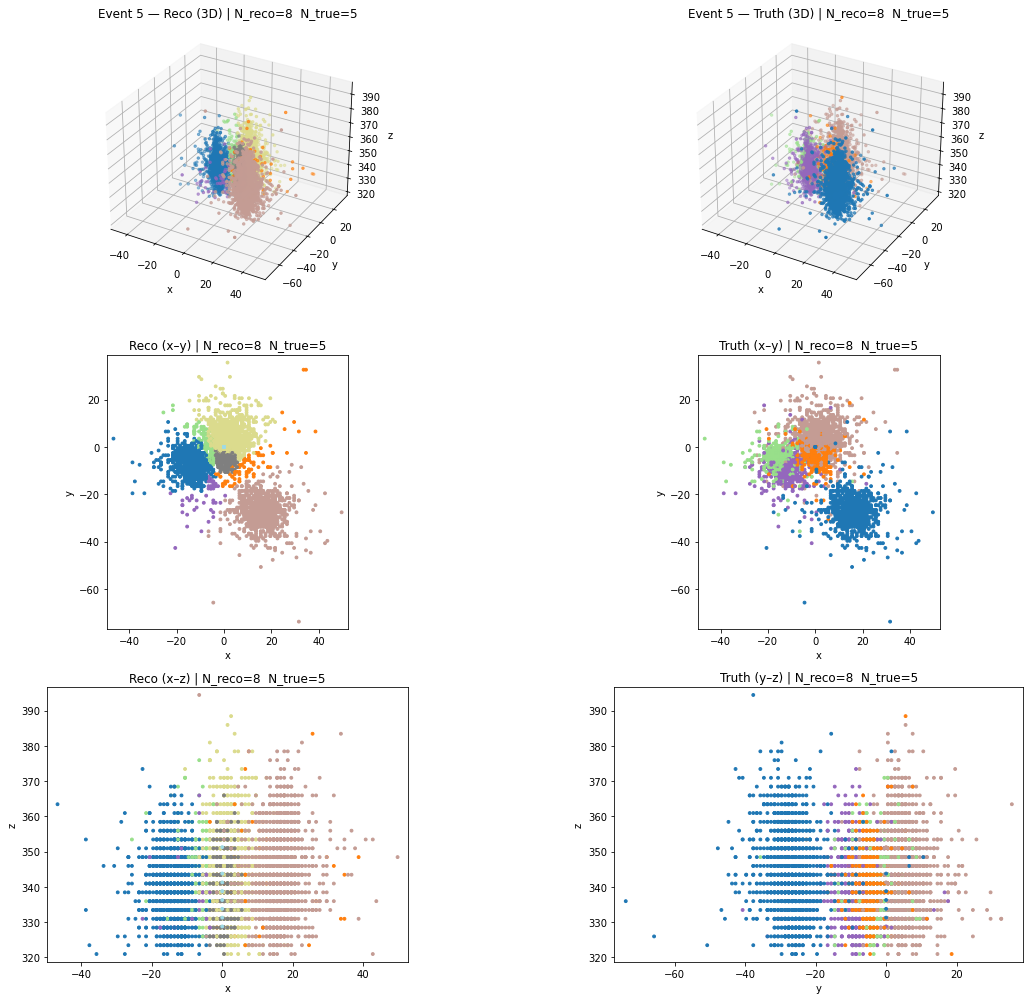

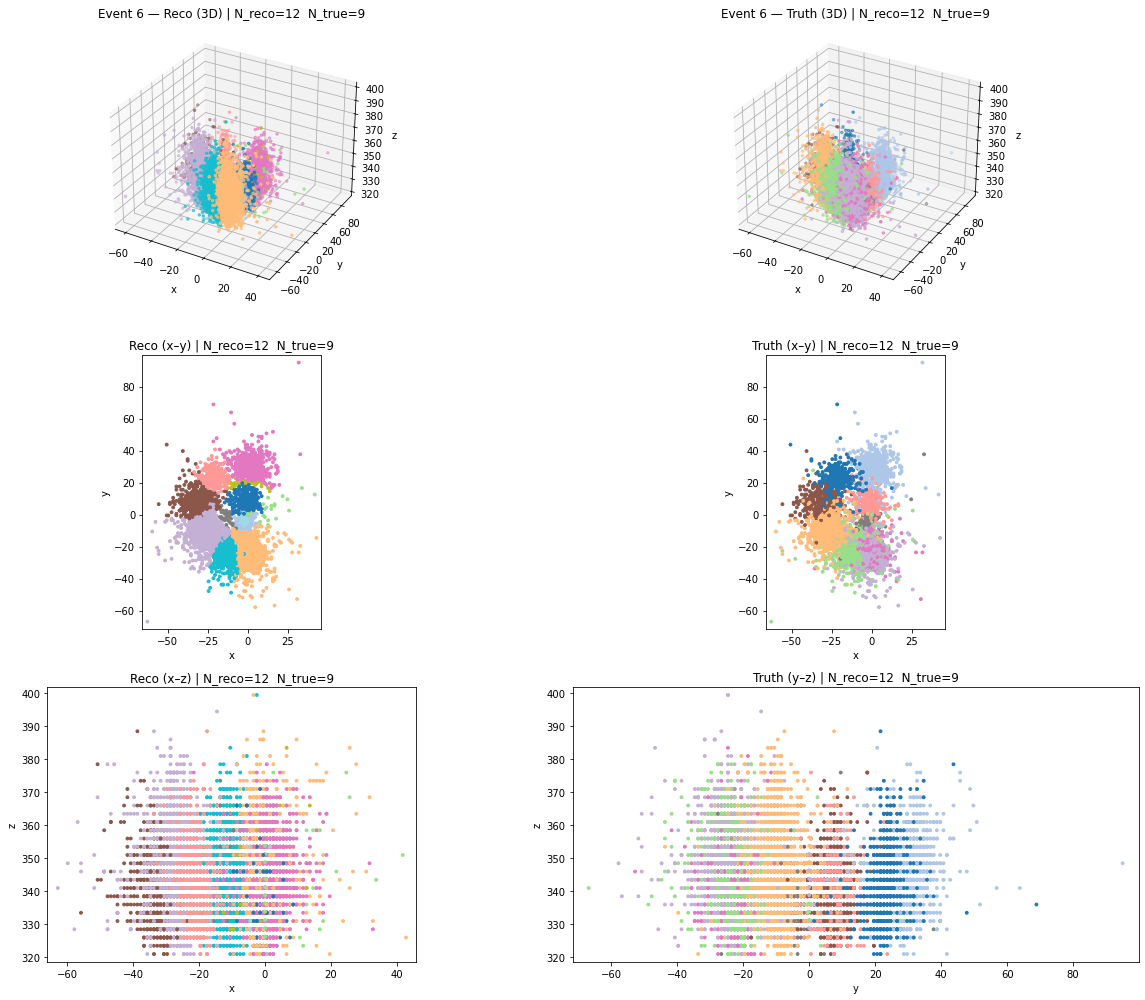

IndexError: list index out of range

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def reco_color_map(labels):
    """
    Map cluster labels so that:
      - noise (-1) -> NaN (drawn as grey by matplotlib, see set_bad below)
      - clusters   -> keep numeric ids
    """
    colors = labels.astype(float)
    colors[colors == -1] = np.nan
    return colors

def count_clusters(labels, noise_label=-1):
    """Number of unique clusters excluding noise_label."""
    u = np.unique(labels)
    return int(np.sum(u != noise_label))

def plot_event_comparison_fixed_limits(xyz, reco_labels, truth_labels, event_id, pad_frac=0.03):
    """
    Plots reco vs truth in:
      - 3D (x,y,z)
      - 2D (x–y), 2D (x–z), 2D (y–z)
    with identical axis limits for easy comparison.

    IMPORTANT: Uses a fixed colormap + fixed vmin/vmax per event so that
    colors are consistent across all subplots within that event.
    Noise (-1) is always grey (via NaN + set_bad).

    xyz: (N,3) numpy array
    reco_labels: (N,) numpy array, with -1 as noise
    truth_labels: (N,) numpy array
    """
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]

    # counts
    n_reco = count_clusters(reco_labels, noise_label=-1)
    n_truth = len(np.unique(truth_labels))

    # fixed limits (same for reco & truth within event)
    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    zmin, zmax = float(z.min()), float(z.max())

    # small padding so points aren't on the frame
    def pad(lo, hi):
        span = hi - lo
        if span == 0:
            span = 1.0
        p = pad_frac * span
        return lo - p, hi + p

    xmin, xmax = pad(xmin, xmax)
    ymin, ymax = pad(ymin, ymax)
    zmin, zmax = pad(zmin, zmax)

    # ---- consistent colors across ALL plots within the event ----
    # Use a *single* colormap object and fixed normalization bounds per event.
    cmap = plt.get_cmap("tab20").copy()
    cmap.set_bad(color="lightgrey")  # NaN -> grey (noise)

    # Fix vmin/vmax so same label -> same color across subplots within the event.
    # (If you have many clusters, tab20 will cycle, but still consistent.)
    vmin = 0
    vmax = int(max(
        np.nanmax(np.where(reco_labels == -1, np.nan, reco_labels)),
        np.max(truth_labels),
        1
    ))

    # map noise to NaN (so it becomes grey via set_bad)
    reco_colors = reco_color_map(reco_labels)

    fig = plt.figure(figsize=(18, 14))

    # Layout: 3 rows x 2 cols
    # Row 1: 3D reco / 3D truth
    # Row 2: xy reco / xy truth
    # Row 3: xz reco / yz truth  (your requested extra plots)

    # -------------------------
    # 3D — RECO
    # -------------------------
    ax1 = fig.add_subplot(321, projection="3d")
    ax1.scatter(x, y, z, c=reco_colors, s=6, cmap=cmap, vmin=vmin, vmax=vmax)
    ax1.set_title(f"Event {event_id} — Reco (3D) | N_reco={n_reco}  N_true={n_truth}")
    ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")
    ax1.set_xlim(xmin, xmax); ax1.set_ylim(ymin, ymax); ax1.set_zlim(zmin, zmax)

    # -------------------------
    # 3D — TRUTH
    # -------------------------
    ax2 = fig.add_subplot(322, projection="3d")
    ax2.scatter(x, y, z, c=truth_labels, s=6, cmap=cmap, vmin=vmin, vmax=vmax)
    ax2.set_title(f"Event {event_id} — Truth (3D) | N_reco={n_reco}  N_true={n_truth}")
    ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z")
    ax2.set_xlim(xmin, xmax); ax2.set_ylim(ymin, ymax); ax2.set_zlim(zmin, zmax)

    # -------------------------
    # 2D — RECO (x–y)
    # -------------------------
    ax3 = fig.add_subplot(323)
    ax3.scatter(x, y, c=reco_colors, s=8, cmap=cmap, vmin=vmin, vmax=vmax)
    ax3.set_title(f"Reco (x–y) | N_reco={n_reco}  N_true={n_truth}")
    ax3.set_xlabel("x"); ax3.set_ylabel("y")
    ax3.set_xlim(xmin, xmax); ax3.set_ylim(ymin, ymax)
    ax3.set_aspect("equal", adjustable="box")

    # -------------------------
    # 2D — TRUTH (x–y)
    # -------------------------
    ax4 = fig.add_subplot(324)
    ax4.scatter(x, y, c=truth_labels, s=8, cmap=cmap, vmin=vmin, vmax=vmax)
    ax4.set_title(f"Truth (x–y) | N_reco={n_reco}  N_true={n_truth}")
    ax4.set_xlabel("x"); ax4.set_ylabel("y")
    ax4.set_xlim(xmin, xmax); ax4.set_ylim(ymin, ymax)
    ax4.set_aspect("equal", adjustable="box")

    # -------------------------
    # 2D — RECO (x–z)  [NEW]
    # -------------------------
    ax5 = fig.add_subplot(325)
    ax5.scatter(x, z, c=reco_colors, s=8, cmap=cmap, vmin=vmin, vmax=vmax)
    ax5.set_title(f"Reco (x–z) | N_reco={n_reco}  N_true={n_truth}")
    ax5.set_xlabel("x"); ax5.set_ylabel("z")
    ax5.set_xlim(xmin, xmax); ax5.set_ylim(zmin, zmax)
    ax5.set_aspect("equal", adjustable="box")

    # -------------------------
    # 2D — TRUTH (y–z)  [NEW]
    # -------------------------
    ax6 = fig.add_subplot(326)
    ax6.scatter(y, z, c=truth_labels, s=8, cmap=cmap, vmin=vmin, vmax=vmax)
    ax6.set_title(f"Truth (y–z) | N_reco={n_reco}  N_true={n_truth}")
    ax6.set_xlabel("y"); ax6.set_ylabel("z")
    ax6.set_xlim(ymin, ymax); ax6.set_ylim(zmin, zmax)
    ax6.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()


# -------------------------
# Example: collect xyz + truth from your DataLoader
# -------------------------
all_xyz = []
all_truth = []

for i, data in enumerate(loader):
    data = data.to(device)

    xyz = data.x[:, :3].detach().cpu().numpy()
    truth = data.assoc.detach().cpu().numpy()

    all_xyz.append(xyz)
    all_truth.append(truth)

    # reco labels already exist in:
    # all_cluster_labels[i]


# -------------------------
# Plot a few events
# -------------------------
n_events_to_plot = 18

for i in range(min(n_events_to_plot, len(all_xyz))):
    plot_event_comparison_fixed_limits(
        xyz=all_xyz[i],
        reco_labels=np.asarray(all_cluster_labels[i]),
        truth_labels=all_truth[i],
        event_id=i
    )


In [ ]:
n_events_to_plot = 9

for i in range(min(n_events_to_plot, len(all_xyz))):
    plot_event_comparison_fixed_limits(
        xyz=all_xyz[i],
        reco_labels=np.asarray(all_cluster_labels[i]),
        truth_labels=all_truth[i],
        event_id=i
    )
